# **MÓDULO 32 - Exercício**
# Random Forest


Nesta tarefa, vocês vão trabalhar com uma base de dados de avaliações de vinhos, onde o objetivo é prever a pontuação dos vinhos usando o algoritmo de Random Forest para classificação multiclasse.

In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("winequality-red.csv", delimiter=',')

df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


**Vamos conhecer nossa base:**

Características dos Vinhos (Features)

Fixed Acidity: Acidez fixa do vinho.

Volatile Acidity: Acidez volátil do vinho.

Citric Acid: Quantidade de ácido cítrico no vinho.

Residual Sugar: Açúcar residual presente no vinho.

Chlorides: Nível de cloretos no vinho.

Free Sulfur Dioxide: Dióxido de enxofre livre no vinho.

Total Sulfur Dioxide: Quantidade total de dióxido de enxofre no vinho.

Density: Densidade do vinho.

pH: Nível de pH do vinho.

Sulphates: Quantidade de sulfatos no vinho.

Alcohol: Teor alcoólico do vinho.



**Variável de Saída (Target):**

Quality: Pontuação do vinho baseada em dados sensoriais, variando de 0 a 10.


Esta abordagem permitirá que vocês explorem como diferentes características químicas influenciam a qualidade dos vinhos e como o Random Forest pode ser usado para fazer previsões precisas com base nesses dados.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [3]:
# Verificando os tipos de dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


#### Nota-se que não há dados faltantes no DataFrame.

# 2 - Realize a segunda e terceita etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.

B) Verifique o balanceamento da váriavel Target.

C)  Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.

D) Crie um novo dataframe apenas com as váriaveis que parecem ter maior correlação com a target. (Negativa ou positiva)


### A)

In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


As colunas `fixed acidity`, `residual sugar`, `chlorides` e `total sulfur dioxide` possuem a mediana consideravelmente menor do que a média, isso indica há a presença de outliers.

Já as colunas `citric acid` e `sulphates` apresentam média e mediana parecidas, no entando o valor máximo parece muito maior que os demais, o que parece indicar outliers.

Vamos plotar os boxplots dessas colunas para verificar visualmente se há ou não outliers.

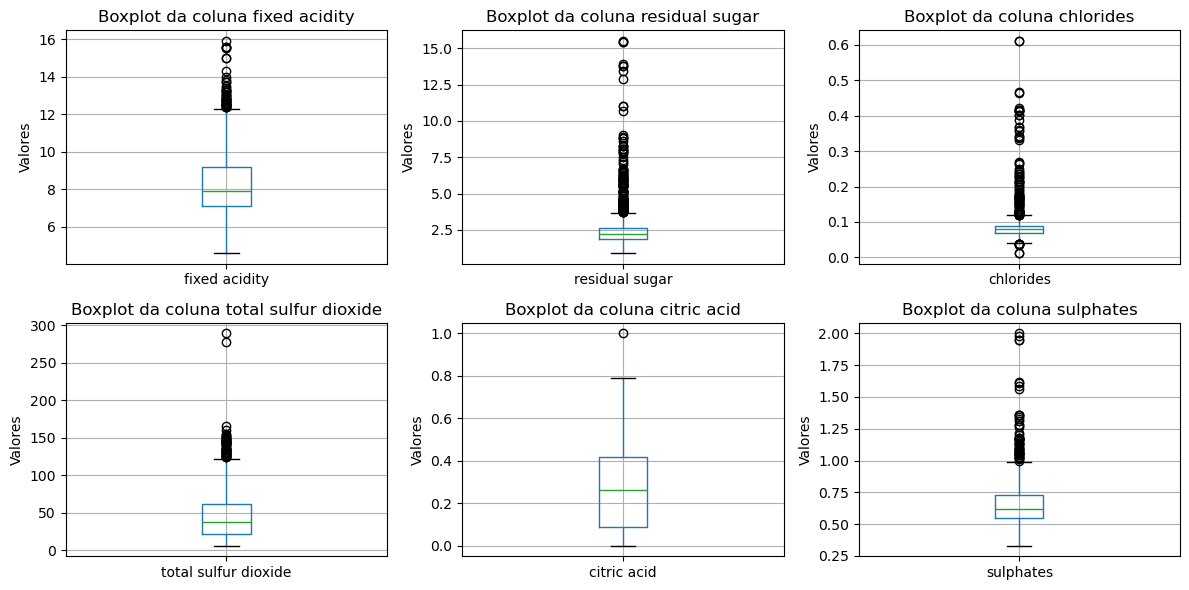

In [5]:
# Cria figura com 2 linhas e 3 colunas
fig, axs = plt.subplots(2, 3, figsize=(12, 6))

# Flatten transforma matriz em vetor para facilitar o loop
axs = axs.flatten()

# Coloca o nome das colunas em uma lista
col_name=['fixed acidity','residual sugar','chlorides','total sulfur dioxide','citric acid','sulphates']

# Cria os 6 gráficos
for i in range(6):
    df.boxplot(column=col_name[i], ax=axs[i])
    axs[i].set_title(f'Boxplot da coluna {col_name[i]}')
    axs[i].set_ylabel('Valores')

# Ajusta espaçamento
plt.tight_layout()

# Exibe
plt.show()

As seis colunas analisadas apresentam presença de outliers. Como a maioria delas possui muitos pontos fora dos quartis, optou-se por remover apenas os valores extremamente acima da distribuição principal dos dados, evitando uma eliminação excessiva de amostras.

Os limites definidos para remoção foram:
* `fixed acidity`: valores acima de 14
* `residual sugar`: valores acima de 10
* `chlorides`: valores acima de 0.3
* `total sulfur dioxide`: valores acima de 250
* `citric acid`: valores acima de 0.9
* `sulphates`: valores acima de 1.5

Esses limites foram definidos de forma empírica, com base na análise visual dos boxplots e na interpretação dos dados durante a etapa exploratória.

In [6]:
# Copia o dataframe original
df_sem_outliers = df.copy()

# Configurando os limites
limites = [14, 10, 0.3, 250, 0.9, 1.5]

# removendo os outliers
for i in range(6):
    df_sem_outliers = df_sem_outliers[df_sem_outliers[col_name[i]] <= limites[i]]

In [7]:
df_sem_outliers.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1551.000000,1551.000000,1551.000000,1551.000000,1551.000000,1551.000000,1551.000000,1551.000000,1551.000000,1551.000000,1551.000000,1551.000000
mean,8.281238,0.529394,0.264249,2.458124,0.082643,15.737589,45.720181,0.996694,3.318343,0.646325,10.441618,5.638943
std,1.682817,0.179541,0.190926,1.057760,0.025446,10.254211,31.564538,0.001830,0.149015,0.139879,1.057557,0.808746
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.870000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995575,3.220000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.089000,21.000000,61.000000,0.997800,3.400000,0.720000,11.100000,6.000000
max,14.000000,1.580000,0.790000,9.000000,0.270000,68.000000,165.000000,1.002890,4.010000,1.360000,14.000000,8.000000


### B)

In [8]:
# Verifica o balanceamento da coluna 'quality'
df['quality'].value_counts(normalize=True) * 100

quality
5    42.589118
6    39.899937
7    12.445278
4     3.314572
8     1.125704
3     0.625391
Name: proportion, dtype: float64

É possível observar claramente que a variável alvo apresenta desbalanceamento entre as classes. As notas 5, 6 e 7 possuem uma quantidade de ocorrências significativamente maior em comparação às notas 3, 4 e 8.

Além disso, as notas 0, 1, 2, 9 e 10 não estão presentes no conjunto de dados, indicando que algumas classes simplesmente não possuem amostras registradas.

### C)

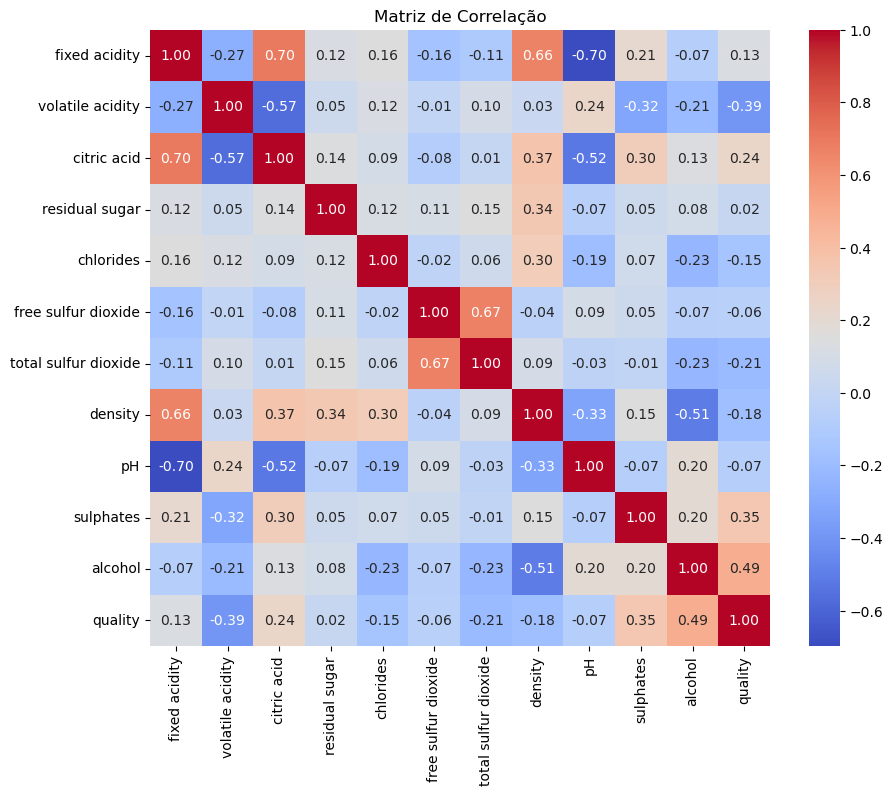

In [9]:
# Matriz de correlação
correlation_matrix = df_sem_outliers.select_dtypes(include=['number']).corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

As variaveis que possuem maior correlação direta com a variável `quality` são `alcohol`, `sulphates`, `citric acid` e `fixed acidity`.
As variáveis que possuem maior correlação inversa com a variaável `quality` são `volatile acidity`, `total sulfur dioxide`, `density` e `chlorides`.

### D)

In [10]:
# Criando um dataframe apenas com as variáveis com correlação forte
df_tratado = df_sem_outliers[['fixed acidity','volatile acidity','citric acid','chlorides','total sulfur dioxide',
                              'density','sulphates','alcohol','quality']]

In [11]:
df_tratado

,fixed acidity,volatile acidity,citric acid,chlorides,total sulfur dioxide,density,sulphates,alcohol,quality
0,7.4,0.700,0.00,0.076,34.0,0.99780,0.56,9.4,5
1,7.8,0.880,0.00,0.098,67.0,0.99680,0.68,9.8,5
2,7.8,0.760,0.04,0.092,54.0,0.99700,0.65,9.8,5
3,11.2,0.280,0.56,0.075,60.0,0.99800,0.58,9.8,6
4,7.4,0.700,0.00,0.076,34.0,0.99780,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,0.090,44.0,0.99490,0.58,10.5,5
1595,5.9,0.550,0.10,0.062,51.0,0.99512,0.76,11.2,6
1596,6.3,0.510,0.13,0.076,40.0,0.99574,0.75,11.0,6
1597,5.9,0.645,0.12,0.075,44.0,0.99547,0.71,10.2,5


# 3 - Preparação Final dos Dados

A) Separe a base em X(Features) e Y(Target)

B) Separe a base em treino e teste.


### A)

In [12]:
# Separando em X (variáveis de entrada) e Y (variável de saída)
X = df_tratado.drop('quality', axis=1)  # X contém todas as colunas exceto 'quality'
Y = df_tratado['quality']  # Y contém apenas a coluna 'quality'

### B)

In [13]:
# Separar em base de treino e teste (usando 80% para treino e 20% para teste)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=40)

# 4 - Modelagem

A) Inicie e treine o modelo de Random Forest

B) Aplique a base de teste o modelo.


### A)

In [14]:
# Iniciando o modelo Random Forest
rf_model = RandomForestClassifier(random_state=41)

# Treinando o modelo
rf_model.fit(X_train, Y_train)

RandomForestClassifier(random_state=41)

### B)

In [15]:
# Fazendo previsões no conjunto de teste
Y_pred = rf_model.predict(X_test)
Y_pred

array([5, 7, 5, 5, 5, 6, 5, 6, 6, 6, 5, 6, 5, 7, 6, 5, 6, 6, 6, 6, 5, 6,
       5, 6, 6, 6, 5, 5, 6, 6, 6, 5, 6, 6, 5, 6, 7, 5, 5, 6, 5, 5, 5, 6,
       6, 6, 6, 6, 5, 6, 6, 5, 6, 6, 5, 6, 5, 6, 6, 5, 5, 6, 6, 6, 6, 5,
       5, 6, 5, 6, 5, 7, 6, 7, 6, 5, 7, 5, 6, 5, 6, 5, 7, 5, 6, 6, 6, 6,
       5, 5, 7, 6, 5, 6, 6, 5, 5, 5, 6, 6, 6, 5, 6, 5, 5, 8, 5, 6, 6, 5,
       6, 5, 5, 7, 5, 6, 6, 5, 5, 5, 6, 6, 5, 7, 6, 5, 6, 6, 5, 6, 5, 7,
       5, 6, 6, 5, 6, 7, 6, 5, 5, 6, 6, 5, 5, 6, 5, 6, 6, 5, 6, 6, 5, 7,
       6, 5, 5, 6, 5, 6, 5, 6, 5, 6, 7, 5, 5, 5, 6, 7, 5, 6, 6, 5, 6, 6,
       5, 5, 5, 7, 5, 5, 6, 6, 5, 6, 6, 5, 5, 8, 7, 6, 5, 6, 5, 6, 5, 6,
       6, 5, 5, 5, 7, 5, 5, 5, 6, 5, 5, 6, 6, 6, 6, 5, 6, 5, 6, 6, 6, 6,
       6, 7, 5, 5, 6, 5, 5, 5, 7, 5, 5, 5, 6, 6, 5, 6, 5, 5, 5, 6, 6, 6,
       5, 6, 5, 5, 6, 6, 5, 5, 6, 7, 5, 7, 5, 7, 7, 6, 6, 5, 5, 7, 6, 7,
       6, 7, 5, 5, 5, 6, 5, 5, 7, 6, 6, 6, 5, 7, 6, 6, 5, 6, 6, 5, 5, 5,
       7, 5, 5, 5, 7, 5, 6, 5, 5, 5, 5, 5, 7, 6, 5,

# 5 - Avaliação

A) Avalie as principais métricas da Classificação e traga insights acerca do resultado, interprete os valores achados.

B) Você nota que o modelo teve dificuldade para prever alguma classe? Se sim, acredita que tenha relação com o balanceamento dos dados? Explique.


### A)

In [16]:
# Avaliando o modelo
accuracy = accuracy_score(Y_test, Y_pred)
report = classification_report(Y_test, Y_pred)

print(f"Acurácia: {accuracy:.2f}")
print("Relatório de Classificação:\n", report)

Acurácia: 0.69
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         6
           5       0.80      0.81      0.81       139
           6       0.61      0.70      0.65       117
           7       0.56      0.44      0.49        41
           8       0.50      0.25      0.33         4

    accuracy                           0.69       311
   macro avg       0.41      0.37      0.38       311
weighted avg       0.67      0.69      0.67       311



C:\Users\lucas\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\lucas\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\lucas\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


A acurácia geral do modelo foi de 69%, um resultado considerado moderado e ainda abaixo do ideal.

O modelo não conseguiu prever corretamente nenhum dos casos das classes 3 e 4. Por outro lado, apresentou desempenho satisfatório na classe 5, alcançando cerca de 80% de precisão, recall e f1-score. Esses resultados indicam que o modelo teve maior facilidade em identificar determinadas classes, enquanto encontrou dificuldades para reconhecer outras.

### B)

O modelo apresentou dificuldade em prever determinadas classes, principalmente devido ao desbalanceamento dos dados. As classes com menor quantidade de amostras foram justamente aquelas em que o modelo mais cometeu erros, enquanto as classes mais representadas obtiveram resultados significativamente melhores.

Isso pode ser observado ao analisar as classes majoritárias 5, 6 e 7. A classe 5, que possui a maior quantidade de amostras, apresentou o melhor desempenho, com métricas de precisão, recall e f1-score em torno de 80%. Em seguida, a classe 6 obteve resultados intermediários, com métricas próximas de 65%. Já a classe 7 apresentou o pior desempenho entre as classes majoritárias, com valores próximos de 50%.

Esses resultados mostram uma relação direta entre a quantidade de exemplos disponíveis para cada classe e a capacidade do modelo de realizar previsões corretas.

# 6 - Melhorando os Hyperparametros

A) Defina o Grid de parametros que você quer testar

B) Inicie e Treine um novo modelo utilizando o random search.

C) Avalie os resultados do modelo.

D) Você identificou melhorias no modelo após aplicar o random search? Justifique.


ps. Essa parte da atividade demorará um pouco para rodar!

### A)

In [17]:
# Definir o espaço de busca dos hiperparâmetros
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

### B)

In [18]:
# Configurando o Randomized Search
random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_grid,
                                   n_iter=100, cv=5, n_jobs=-1, verbose=2, random_state=40, scoring='accuracy')

# Executando o Randomized Search
random_search.fit(X_train, Y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=41),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200]},
                   random_state=40, scoring='accuracy', verbose=2)

In [19]:
# Obtendo os melhores hiperparâmetros através do método randomico
best_params = random_search.best_params_
print(f"Melhores Hiperparâmetros: {best_params}")

Melhores Hiperparâmetros: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}


In [20]:
# Treinando o modelo com os melhores hiperparâmetros encontrados acima
best_rf_model = random_search.best_estimator_
best_rf_model.fit(X_train, Y_train)

RandomForestClassifier(max_features='log2', min_samples_leaf=2, random_state=41)

In [21]:
# Fazendo previsões no conjunto de teste
Y_pred = best_rf_model.predict(X_test)

# Avaliando o modelo
accuracy = accuracy_score(Y_test, Y_pred)
report = classification_report(Y_test, Y_pred)

print(f"Acurácia: {accuracy:.2f}")
print("Relatório de Classificação:\n", report)

Acurácia: 0.69
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         6
           5       0.81      0.81      0.81       139
           6       0.61      0.73      0.66       117
           7       0.58      0.44      0.50        41
           8       0.00      0.00      0.00         4

    accuracy                           0.69       311
   macro avg       0.33      0.33      0.33       311
weighted avg       0.67      0.69      0.67       311



C:\Users\lucas\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\lucas\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\lucas\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### C) e D)

O modelo continuou apresentando resultados muito semelhantes aos obtidos anteriormente. A classe 5 manteve o melhor desempenho, com métricas próximas de 81%, enquanto a classe 6 permaneceu em torno de 65% e a classe 7 apresentou valores próximos de 50%.

Além disso, a acurácia geral do modelo permaneceu inalterada em 69%.

As classes 3 e 4 continuaram sem nenhum acerto e, após a otimização, a classe 8 também passou a não apresentar previsões corretas.

Dessa forma, a otimização de hiperparâmetros utilizando o RandomizedSearchCV não trouxe melhorias significativas para o desempenho da Random Forest.

# 7 - Chegando a perfeição

Baseado em tudo que você já aprendeu até agora, quais outras técnicas você acredita que poderiam ser aplicadas ao modelo para melhorar ainda mais suas previsões?

### <u>Sim</u>
O balanceamento dos dados provavelmente contribuiria para melhorar o desempenho do modelo. Técnicas de balanceamento poderiam gerar amostras sintéticas para as classes minoritárias, reduzindo a diferença na quantidade de exemplos entre as classes. Dessa forma, o modelo teria condições mais equilibradas para aprender os padrões de todas as categorias, e não apenas das classes majoritárias.

Outra estratégia que poderia melhorar os resultados seria a padronização dos dados. Ao colocar as variáveis na mesma escala, o modelo passaria a tratar todas as features de maneira mais equilibrada, evitando que variáveis com valores maiores exerçam influência excessiva durante o treinamento.